In [112]:
# ================================================
# CELDA 1 - Imports
# ================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob, io, requests

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

plt.rcParams['figure.figsize'] = (10,6)
sns.set(style="whitegrid")


In [113]:
# ================================================
# CELDA 2 - Cargar dataset
# ================================================

github_raw_url = ("https://raw.githubusercontent.com/"
                  "Dilan140402/Analitica-Datos/"
                  "61f05dd96a1f6e07a1721930ef267b11651f18c9/"
                  "data/citybike_lima.csv")

local_files = glob.glob("*citybike*.csv") + glob.glob("*city*.csv")

def load_citybike(url, local_files):
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            print("CSV cargado desde GitHub.")
            return pd.read_csv(io.StringIO(r.text))
    except:
        print("Fallo descarga. Probando archivos locales...")

    for f in local_files:
        try:
            print("Cargando local:", f)
            return pd.read_csv(f)
        except:
            pass
    raise FileNotFoundError("No se encontró archivo válido.")

df = load_citybike(github_raw_url, local_files)
df.head()


CSV cargado desde GitHub.


,scrape_timestamp,station_id,station_name,lat,lon,capacity,free_bikes,empty_slots,day_of_week,periodo_dia,weather_main,weather_desc,temp_C,wind_speed,clima_miraflores,temp_miraflores,in_miraflores
0,2025-10-01T11:34:22.005486-05:00,008a35afc6b4060be57b48bf90bec44c,18027 Ov. Julio Ramón Riveyro - Av. Pardo,-12.119013,-77.039928,14,8,6,Wednesday,mañana,NaN,NaN,19.0,NaN,Clima: pronóstico del tiempo,19.0,True
1,2025-10-01T11:34:22.005486-05:00,03367da30caea302b11c838d8b98df55,18009 Ca. Luis Schereiber Cdra. 2 (C.C. Aurora),-12.122125,-77.011506,16,8,8,Wednesday,mañana,NaN,NaN,19.0,NaN,Clima: pronóstico del tiempo,19.0,False
2,2025-10-01T11:34:22.005486-05:00,06dd87a8b87232577015b1c9a4ba08ed,18024 Ov. Bolognesi - Ca. Madrid,-12.123368,-77.035637,14,3,11,Wednesday,mañana,NaN,NaN,19.0,NaN,Clima: pronóstico del tiempo,19.0,True
3,2025-10-01T11:34:22.005486-05:00,0927eccbf04e2aadd179595c55c52bbe,18047 Malecón Cisneros - Ca. Trípoli,-12.125037,-77.037307,16,9,7,Wednesday,mañana,NaN,NaN,19.0,NaN,Clima: pronóstico del tiempo,19.0,True
4,2025-10-01T11:34:22.005486-05:00,0ac132eb1a147b7b23a753185cbebd1d,18026 Malecón de la Marina - Parque Grau,-12.118497,-77.045048,20,11,9,Wednesday,mañana,NaN,NaN,19.0,NaN,Clima: pronóstico del tiempo,19.0,True


In [114]:
# ================================================
# CELDA 3 - Procesamiento básico y cálculo de promedios diarios
# ================================================

# Convertir timestamp
df["scrape_timestamp"] = pd.to_datetime(df["scrape_timestamp"], errors="coerce")

# Crear columna fecha
df["date"] = df["scrape_timestamp"].dt.date

# Limpiar datos
df_clean = df.dropna(subset=["date", "free_bikes"])

# Promedio diario por estación
promedio_diario = (
    df_clean.groupby(["station_name", "date"])["free_bikes"]
    .mean()
    .reset_index()
    .sort_values(["station_name", "date"])
)

print("Promedio diario de bicicletas por estación:")
display(promedio_diario.head())


Promedio diario de bicicletas por estación:


,station_name,date,free_bikes
0,18001 Ca. Oscar R. Benavides - Ca. Schell (Par...,2025-10-01,11.217391
1,18001 Ca. Oscar R. Benavides - Ca. Schell (Par...,2025-10-02,12.906977
2,18001 Ca. Oscar R. Benavides - Ca. Schell (Par...,2025-10-03,10.512195
3,18001 Ca. Oscar R. Benavides - Ca. Schell (Par...,2025-10-04,11.214286
4,18001 Ca. Oscar R. Benavides - Ca. Schell (Par...,2025-10-05,5.261905


In [ ]:
# ================================================
# CELDA 4 - Gráficos
# ================================================

stations = promedio_diario["station_name"].unique()
print("Total de estaciones:", len(stations))

for station in stations:
    subset = promedio_diario[promedio_diario["station_name"] == station]

    plt.figure(figsize=(12,4))
    plt.plot(subset["date"], subset["free_bikes"], marker="o", linewidth=2)

    plt.title(f"Promedio diario de bicicletas disponibles - {station}")
    plt.xlabel("Fecha")
    plt.ylabel("Promedio de bicicletas disponibles")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [116]:
# ================================================
# CELDA 5 - Limpieza avanzada y creación de features
# ================================================

# Normalizar nombres de columnas
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Convertir timestamp
df['scrape_timestamp'] = pd.to_datetime(df['scrape_timestamp'], errors='coerce')

# Nuevas columnas útiles
df['hour'] = df['scrape_timestamp'].dt.hour
df['weekday'] = df['scrape_timestamp'].dt.weekday

# Convertir booleanos (solo si aplica)
if 'in_miraflores' in df.columns:
    df['in_miraflores'] = df['in_miraflores'].astype(str).str.lower().map({
        'true': True, '1': True, 't': True,
        'false': False, '0': False, 'f': False
    })

print("Nulos por columna:")
print(df.isnull().sum())

df.head()


Nulos por columna:
scrape_timestamp         0
station_id               0
station_name             0
lat                      0
lon                      0
capacity                 0
free_bikes               0
empty_slots              0
day_of_week              0
periodo_dia              0
weather_main        113138
weather_desc        113138
temp_c                1850
wind_speed          113138
clima_miraflores      1850
temp_miraflores       1850
in_miraflores            0
date                     0
hour                     0
weekday                  0
dtype: int64


,scrape_timestamp,station_id,station_name,lat,lon,capacity,free_bikes,empty_slots,day_of_week,periodo_dia,weather_main,weather_desc,temp_c,wind_speed,clima_miraflores,temp_miraflores,in_miraflores,date,hour,weekday
0,2025-10-01 11:34:22.005486-05:00,008a35afc6b4060be57b48bf90bec44c,18027 Ov. Julio Ramón Riveyro - Av. Pardo,-12.119013,-77.039928,14,8,6,Wednesday,mañana,NaN,NaN,19.0,NaN,Clima: pronóstico del tiempo,19.0,True,2025-10-01,11,2
1,2025-10-01 11:34:22.005486-05:00,03367da30caea302b11c838d8b98df55,18009 Ca. Luis Schereiber Cdra. 2 (C.C. Aurora),-12.122125,-77.011506,16,8,8,Wednesday,mañana,NaN,NaN,19.0,NaN,Clima: pronóstico del tiempo,19.0,False,2025-10-01,11,2
2,2025-10-01 11:34:22.005486-05:00,06dd87a8b87232577015b1c9a4ba08ed,18024 Ov. Bolognesi - Ca. Madrid,-12.123368,-77.035637,14,3,11,Wednesday,mañana,NaN,NaN,19.0,NaN,Clima: pronóstico del tiempo,19.0,True,2025-10-01,11,2
3,2025-10-01 11:34:22.005486-05:00,0927eccbf04e2aadd179595c55c52bbe,18047 Malecón Cisneros - Ca. Trípoli,-12.125037,-77.037307,16,9,7,Wednesday,mañana,NaN,NaN,19.0,NaN,Clima: pronóstico del tiempo,19.0,True,2025-10-01,11,2
4,2025-10-01 11:34:22.005486-05:00,0ac132eb1a147b7b23a753185cbebd1d,18026 Malecón de la Marina - Parque Grau,-12.118497,-77.045048,20,11,9,Wednesday,mañana,NaN,NaN,19.0,NaN,Clima: pronóstico del tiempo,19.0,True,2025-10-01,11,2


In [117]:
# ======================================================
# CELDA FINAL — DETECCIÓN, FILTRADO E IMPUTACIÓN SEGURA
# ======================================================

from sklearn.impute import SimpleImputer

# 1) Normalizar nombres de columnas
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# 1.1 ELIMINAR columnas duplicadas
df = df.loc[:, ~df.columns.duplicated()]
print("✔ Columnas únicas aseguradas")

target = "free_bikes"
if target not in df.columns:
    raise ValueError("No encontré la columna free_bikes en el DataFrame")

# 2) Convertir columnas object a número si tiene sentido
for col in df.columns:
    if df[col].dtype == "object":
        converted = pd.to_numeric(df[col], errors="coerce")
        if converted.notna().mean() > 0.7:  # si más del 70% puede ser número
            df[col] = converted

# 3) Detectar columnas numéricas reales
num_features = [
    col for col in df.columns
    if pd.api.types.is_numeric_dtype(df[col]) and col != target
]

# 3.1 Eliminar columnas numéricas completamente vacías
empty_num_cols = [col for col in num_features if df[col].isna().sum() == len(df)]
if empty_num_cols:
    print("⚠ Columnas numéricas eliminadas por estar vacías:", empty_num_cols)
    num_features = [col for col in num_features if col not in empty_num_cols]

# 4) Detectar columnas categóricas reales
cat_features = [
    col for col in df.columns
    if df[col].dtype in ["object", "bool"]
]

print("✔ Num features finales:", num_features)
print("✔ Cat features finales:", cat_features)

# 5) Crear df_model limpio con columnas únicas
use_cols = list(dict.fromkeys(num_features + cat_features + [target]))
df_model = df[use_cols].copy()

# 6) Crear imputadores
num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="constant", fill_value="__missing__")

# 7) Imputación segura (sin columnas fantasma)
df_model[num_features] = pd.DataFrame(
    num_imputer.fit_transform(df_model[num_features]),
    columns=num_features,
    index=df_model.index
)

df_model[cat_features] = pd.DataFrame(
    cat_imputer.fit_transform(df_model[cat_features]),
    columns=cat_features,
    index=df_model.index
)

print("\n🎉 Imputación completada sin errores")
df_model.head()


✔ Columnas únicas aseguradas
⚠ Columnas numéricas eliminadas por estar vacías: ['weather_main', 'weather_desc', 'wind_speed']
✔ Num features finales: ['lat', 'lon', 'capacity', 'empty_slots', 'temp_c', 'temp_miraflores', 'in_miraflores', 'hour', 'weekday']
✔ Cat features finales: ['station_id', 'station_name', 'day_of_week', 'periodo_dia', 'clima_miraflores', 'in_miraflores', 'date']

🎉 Imputación completada sin errores


,lat,lon,capacity,empty_slots,temp_c,temp_miraflores,in_miraflores,hour,weekday,station_id,station_name,day_of_week,periodo_dia,clima_miraflores,date,free_bikes
0,-12.119013,-77.039928,14.0,6.0,19.0,19.0,1.0,11.0,2.0,008a35afc6b4060be57b48bf90bec44c,18027 Ov. Julio Ramón Riveyro - Av. Pardo,Wednesday,mañana,Clima: pronóstico del tiempo,2025-10-01,8
1,-12.122125,-77.011506,16.0,8.0,19.0,19.0,0.0,11.0,2.0,03367da30caea302b11c838d8b98df55,18009 Ca. Luis Schereiber Cdra. 2 (C.C. Aurora),Wednesday,mañana,Clima: pronóstico del tiempo,2025-10-01,8
2,-12.123368,-77.035637,14.0,11.0,19.0,19.0,1.0,11.0,2.0,06dd87a8b87232577015b1c9a4ba08ed,18024 Ov. Bolognesi - Ca. Madrid,Wednesday,mañana,Clima: pronóstico del tiempo,2025-10-01,3
3,-12.125037,-77.037307,16.0,7.0,19.0,19.0,1.0,11.0,2.0,0927eccbf04e2aadd179595c55c52bbe,18047 Malecón Cisneros - Ca. Trípoli,Wednesday,mañana,Clima: pronóstico del tiempo,2025-10-01,9
4,-12.118497,-77.045048,20.0,9.0,19.0,19.0,1.0,11.0,2.0,0ac132eb1a147b7b23a753185cbebd1d,18026 Malecón de la Marina - Parque Grau,Wednesday,mañana,Clima: pronóstico del tiempo,2025-10-01,11


In [118]:
print("num_features:", num_features)
print("Cantidad num_features:", len(num_features))
print("Shape antes de imputar:", df_model[num_features].shape)

arr = num_imputer.fit_transform(df_model[num_features])

print("Shape imputado:", arr.shape)


num_features: ['lat', 'lon', 'capacity', 'empty_slots', 'temp_c', 'temp_miraflores', 'in_miraflores', 'hour', 'weekday']
Cantidad num_features: 9
Shape antes de imputar: (113138, 9)
Shape imputado: (113138, 9)


In [35]:
print("Columnas reales en df_model[num_features]:")
print(df_model[num_features].columns.tolist())

Columnas reales en df_model[num_features]:
['lat', 'lon', 'capacity', 'empty_slots', 'temp_c', 'temp_miraflores', 'in_miraflores', 'in_miraflores', 'hour', 'weekday']


In [36]:
print("Todas las columnas de df_model:")
print(df_model.columns.tolist())
print("Cantidad:", len(df_model.columns))

Todas las columnas de df_model:
['lat', 'lon', 'capacity', 'empty_slots', 'temp_c', 'temp_miraflores', 'in_miraflores', 'hour', 'weekday', 'station_id', 'station_name', 'day_of_week', 'periodo_dia', 'clima_miraflores', 'in_miraflores', 'date', 'free_bikes']
Cantidad: 17


In [119]:
# ================================================
# CELDA 4 - Selección de variables y manejo de NaN
# ================================================

# 0) Normalizar columnas y ELIMINAR duplicadas
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df = df.loc[:, ~df.columns.duplicated()]

print("✔ Columnas únicas aseguradas:", len(df.columns))

target = "free_bikes"
if target not in df.columns:
    raise ValueError("No encontré la columna free_bikes en el DataFrame")

# ------------------------------------------------------
# 1. Intentar convertir objetos a número (solo si tiene sentido)
# ------------------------------------------------------
for col in df.columns:
    if df[col].dtype == "object":
        converted = pd.to_numeric(df[col], errors="coerce")
        if converted.notna().mean() > 0.9:  # si 90% es convertible → numérica real
            df[col] = converted

# ------------------------------------------------------
# 2. Detectar correctamente columnas numéricas
# ------------------------------------------------------
num_features = [
    col for col in df.columns
    if pd.api.types.is_numeric_dtype(df[col]) and col != target
]

# Eliminar columnas numéricas completamente vacías
num_features = [
    col for col in num_features
    if df[col].isna().sum() < len(df)
]

# Detectar categóricas
cat_features = [
    col for col in df.columns
    if df[col].dtype == "object" or df[col].dtype == "bool"
]

print("\n✔ Num features finales:", num_features)
print("✔ Cat features finales:", cat_features)

# ------------------------------------------------------
# 3. Crear df_model solo con columnas válidas
# ------------------------------------------------------
use_cols = num_features + cat_features + [target]

# Evitar duplicados aquí también
use_cols = list(dict.fromkeys(use_cols))

df_model = df[use_cols].copy()

# ------------------------------------------------------
# 4. IMPUTACIÓN SEGURA
# ------------------------------------------------------
num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="constant", fill_value="__missing__")

df_model[num_features] = pd.DataFrame(
    num_imputer.fit_transform(df_model[num_features]),
    columns=num_features,
    index=df_model.index
)

df_model[cat_features] = pd.DataFrame(
    cat_imputer.fit_transform(df_model[cat_features]),
    columns=cat_features,
    index=df_model.index
)

print("\n🎉 Imputación completada sin errores")
df_model.head()


✔ Columnas únicas aseguradas: 20

✔ Num features finales: ['lat', 'lon', 'capacity', 'empty_slots', 'temp_c', 'temp_miraflores', 'in_miraflores', 'hour', 'weekday']
✔ Cat features finales: ['station_id', 'station_name', 'day_of_week', 'periodo_dia', 'clima_miraflores', 'in_miraflores', 'date']

🎉 Imputación completada sin errores


,lat,lon,capacity,empty_slots,temp_c,temp_miraflores,in_miraflores,hour,weekday,station_id,station_name,day_of_week,periodo_dia,clima_miraflores,date,free_bikes
0,-12.119013,-77.039928,14.0,6.0,19.0,19.0,1.0,11.0,2.0,008a35afc6b4060be57b48bf90bec44c,18027 Ov. Julio Ramón Riveyro - Av. Pardo,Wednesday,mañana,Clima: pronóstico del tiempo,2025-10-01,8
1,-12.122125,-77.011506,16.0,8.0,19.0,19.0,0.0,11.0,2.0,03367da30caea302b11c838d8b98df55,18009 Ca. Luis Schereiber Cdra. 2 (C.C. Aurora),Wednesday,mañana,Clima: pronóstico del tiempo,2025-10-01,8
2,-12.123368,-77.035637,14.0,11.0,19.0,19.0,1.0,11.0,2.0,06dd87a8b87232577015b1c9a4ba08ed,18024 Ov. Bolognesi - Ca. Madrid,Wednesday,mañana,Clima: pronóstico del tiempo,2025-10-01,3
3,-12.125037,-77.037307,16.0,7.0,19.0,19.0,1.0,11.0,2.0,0927eccbf04e2aadd179595c55c52bbe,18047 Malecón Cisneros - Ca. Trípoli,Wednesday,mañana,Clima: pronóstico del tiempo,2025-10-01,9
4,-12.118497,-77.045048,20.0,9.0,19.0,19.0,1.0,11.0,2.0,0ac132eb1a147b7b23a753185cbebd1d,18026 Malecón de la Marina - Parque Grau,Wednesday,mañana,Clima: pronóstico del tiempo,2025-10-01,11


In [120]:
# CELDA 5 - Train/test y preprocesador
X = df_model[num_features + cat_features]
y = df_model[target].astype(float)

print("Filas disponibles para modelar:", X.shape[0])
if X.shape[0] < 3:
    print("Advertencia: muy pocas filas. Algunos modelos pueden no generalizar.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = ColumnTransformer([
    ("num", "passthrough", num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_features)
], remainder="drop")

Filas disponibles para modelar: 113138


In [121]:
# ================================
# CELDA 6 - Transformación segura
# ================================

# 1) Eliminar columnas duplicadas en X_train / X_test
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_test = X_test.loc[:, ~X_test.columns.duplicated()]

# 2) Asegurar que las listas de columnas no tengan duplicados
num_features = list(dict.fromkeys(num_features))
cat_features = list(dict.fromkeys(cat_features))

# 3) Reconstruir el preprocessor limpio
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ],
    remainder="drop"
)

# 4) Transformar
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# 5) Asegurar que y sea vector columna
y_train_arr = y_train.values.reshape(-1, 1)
y_test_arr = y_test.values.reshape(-1, 1)

print("X_train_proc shape:", X_train_proc.shape)
print("X_test_proc shape:", X_test_proc.shape)
print("y_train shape:", y_train_arr.shape)


X_train_proc shape: (90510, 185)
X_test_proc shape: (22628, 185)
y_train shape: (90510, 1)


In [122]:
# --- ELIMINAR COLUMNAS DUPLICADAS DE X ---

print("Columnas originales:", len(X.columns))
print("Duplicadas:", X.columns[X.columns.duplicated()].tolist())

# quitar duplicadas conservando la primera aparición
X = X.loc[:, ~X.columns.duplicated()]

print("Columnas después de limpiar:", len(X.columns))


Columnas originales: 16
Duplicadas: ['in_miraflores']
Columnas después de limpiar: 15


In [126]:
# --- REPARAR MATRICES DE TRAIN/TEST ---

# Si son sparse, convertirlos a dense:
try:
    X_train_proc_fixed = X_train_proc.toarray()
    X_test_proc_fixed = X_test_proc.toarray()
    print("Sparse → Dense")
except:
    # ya son numpy arrays
    X_train_proc_fixed = np.array(X_train_proc)
    X_test_proc_fixed = np.array(X_test_proc)

print("X_train_proc shape:", X_train_proc_fixed.shape)
print("X_test_proc shape:", X_test_proc_fixed.shape)

# reconstruir matrices con bias
X_train_proc = X_train_proc_fixed
X_test_proc = X_test_proc_fixed



Sparse → Dense
X_train_proc shape: (90510, 185)
X_test_proc shape: (22628, 185)


Ecuación normal vía inversa calculada.
Ecuación Normal → RMSE: 6785554187379946496.0000, R2: -2556450957290730279880635677329588224.0000, MAE: 5385028192376071168.0000
Estaciones seleccionadas: ['18027 Ov. Julio Ramón Riveyro - Av. Pardo'
 '18009 Ca. Luis Schereiber Cdra. 2 (C.C. Aurora)']


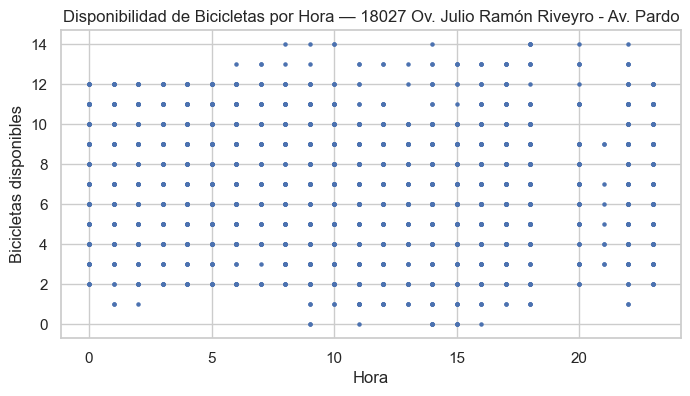

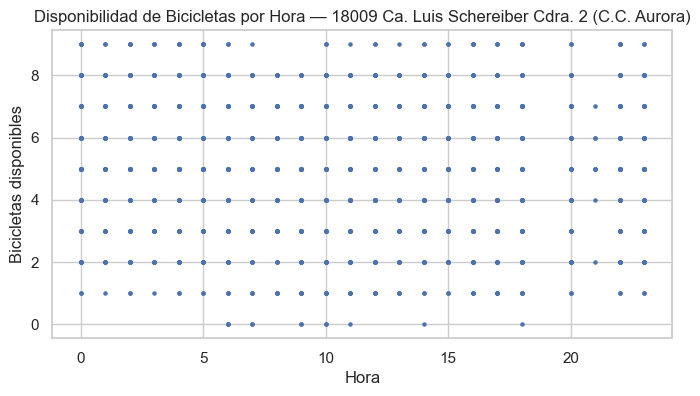

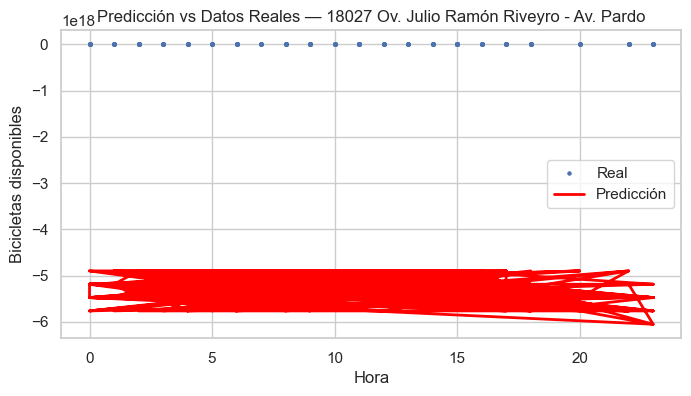

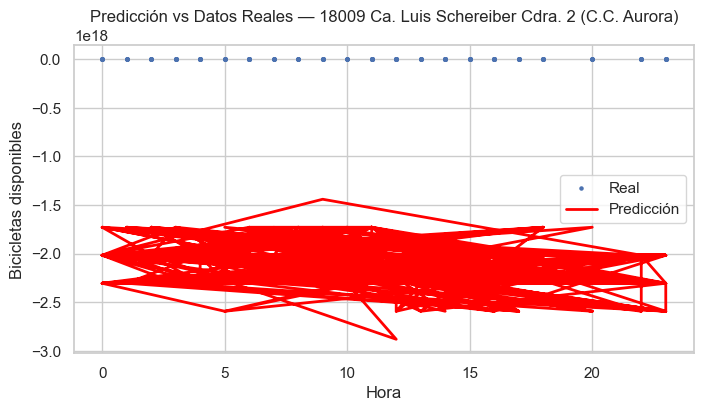

In [128]:
# CELDA — Gráficas de variación por hora y predicción usando Ecuación Normal para 2 estaciones

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


# =========================
#  1. Ecuación Normal
# =========================

# Construir matrices con término bias
Xb = np.c_[np.ones((X_train_proc.shape[0], 1)), X_train_proc]
Xb_test = np.c_[np.ones((X_test_proc.shape[0], 1)), X_test_proc]

try:
    theta_best = np.linalg.inv(Xb.T.dot(Xb)).dot(Xb.T).dot(y_train_arr)
    print("Ecuación normal vía inversa calculada.")
except np.linalg.LinAlgError:
    theta_best = np.linalg.pinv(Xb).dot(y_train_arr)
    print("Matriz singular → usando pseudoinversa (pinv).")

# Predicciones
y_pred_normal = Xb_test.dot(theta_best).flatten()

# Métricas
rmse_normal = np.sqrt(mean_squared_error(y_test_arr, y_pred_normal))
r2_normal = r2_score(y_test_arr, y_pred_normal)
mae_normal = mean_absolute_error(y_test_arr, y_pred_normal)

print(f"Ecuación Normal → RMSE: {rmse_normal:.4f}, R2: {r2_normal:.4f}, MAE: {mae_normal:.4f}")


# =========================
#  2. Seleccionar 2 estaciones (por nombre)
# =========================

stations = df['station_name'].unique()[:2]
print("Estaciones seleccionadas:", stations)

target_col = "free_bikes"


# =========================
#  3. Crear DF para pruebas con nombre de estación y hora
# =========================

X_test_with_station = X_test.copy()

# Recuperar columnas desde el DF original usando los índices
X_test_with_station['station_name'] = df.loc[X_test.index, 'station_name'].values
X_test_with_station['hour'] = df.loc[X_test.index, 'hour'].values

# Agregar datos reales y predicción
X_test_with_station['y_real'] = y_test_arr
X_test_with_station['y_pred'] = y_pred_normal


# =========================
#  4. Gráfica de DISPONIBILIDAD por hora
# =========================

for station in stations:

    df_station = df[df['station_name'] == station]

    plt.figure(figsize=(8,4))
    plt.scatter(df_station['hour'], df_station[target_col], s=5)
    plt.title(f"Disponibilidad de Bicicletas por Hora — {station}")
    plt.xlabel("Hora")
    plt.ylabel("Bicicletas disponibles")
    plt.grid(True)
    plt.show()


# =========================
#  5. Gráfica de PREDICCIÓN vs REAL
# =========================

for station in stations:

    df_pred = X_test_with_station[X_test_with_station['station_name'] == station]

    plt.figure(figsize=(8,4))
    plt.scatter(df_pred['hour'], df_pred['y_real'], s=5, label="Real")
    plt.plot(df_pred['hour'], df_pred['y_pred'], linewidth=2, color='red', label="Predicción")

    plt.title(f"Predicción vs Datos Reales — {station}")
    plt.xlabel("Hora")
    plt.ylabel("Bicicletas disponibles")
    plt.legend()
    plt.grid(True)
    plt.show()


Modelo calculado correctamente usando SVD (np.linalg.lstsq).
Regresión vía pseudoinversa SVD → RMSE: 0.0837, R2: 0.9996, MAE: 0.0244
Estaciones seleccionadas: ['18027 Ov. Julio Ramón Riveyro - Av. Pardo'
 '18009 Ca. Luis Schereiber Cdra. 2 (C.C. Aurora)']


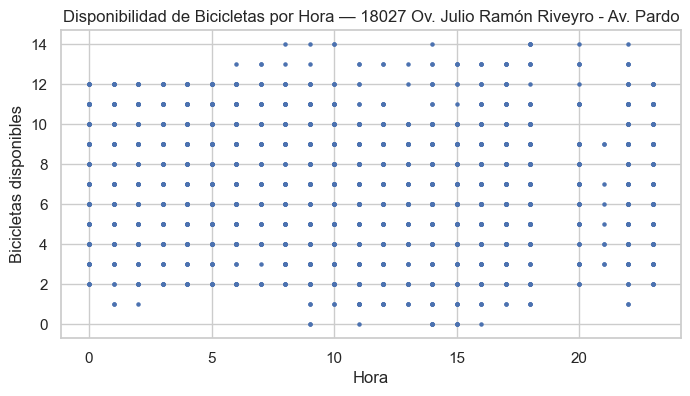

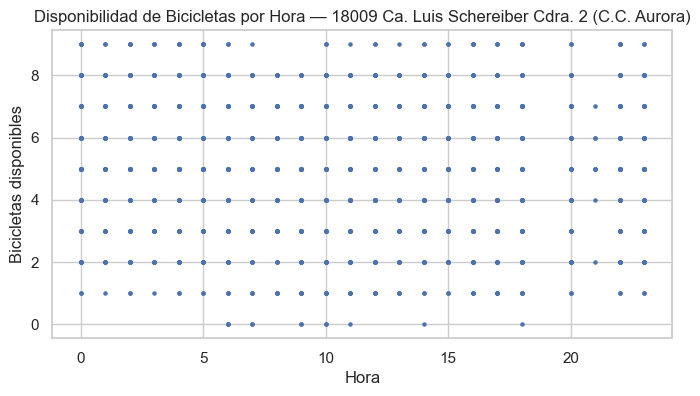

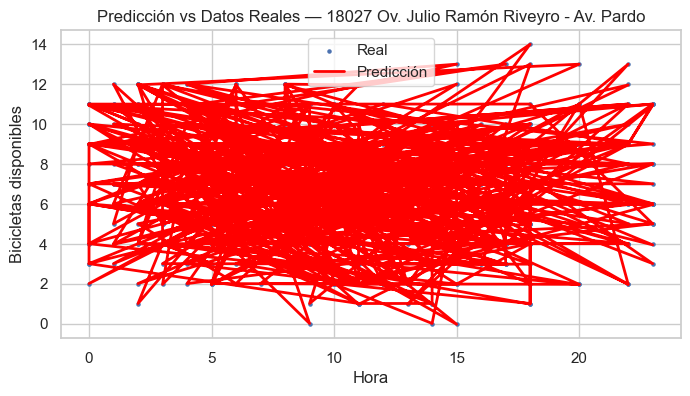

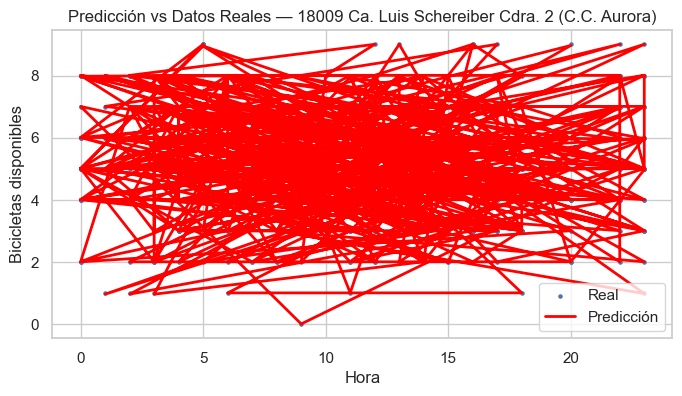

In [133]:
# CELDA — Gráficas de variación por hora y predicción usando pseudoinversa SVD

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


# =========================
#  1. REGRESIÓN USANDO SVD (pseudoinversa)
# =========================

# Construir matrices con término bias
Xb = np.c_[np.ones((X_train_proc.shape[0], 1)), X_train_proc]
Xb_test = np.c_[np.ones((X_test_proc.shape[0], 1)), X_test_proc]

# Usar lstsq --> método recomendado (usa SVD)
theta_best, residuals, rank, s = np.linalg.lstsq(Xb, y_train_arr, rcond=1e-6)
print("Modelo calculado correctamente usando SVD (np.linalg.lstsq).")

# Predicciones
y_pred_normal = Xb_test.dot(theta_best).flatten()

# Métricas
rmse_normal = np.sqrt(mean_squared_error(y_test_arr, y_pred_normal))
r2_normal = r2_score(y_test_arr, y_pred_normal)
mae_normal = mean_absolute_error(y_test_arr, y_pred_normal)

print(f"Regresión vía pseudoinversa SVD → RMSE: {rmse_normal:.4f}, R2: {r2_normal:.4f}, MAE: {mae_normal:.4f}")


# =========================
#  2. Seleccionar 2 estaciones (por nombre)
# =========================

stations = df['station_name'].unique()[:2]
print("Estaciones seleccionadas:", stations)

target_col = "free_bikes"


# =========================
#  3. DF para pruebas con nombre de estación y hora
# =========================

X_test_with_station = X_test.copy()

# Recuperar columnas desde el DF original usando los índices
X_test_with_station['station_name'] = df.loc[X_test.index, 'station_name'].values
X_test_with_station['hour'] = df.loc[X_test.index, 'hour'].values

# Agregar datos reales y predicción
X_test_with_station['y_real'] = y_test_arr
X_test_with_station['y_pred'] = y_pred_normal


# =========================
#  4. Gráfica de DISPONIBILIDAD por hora
# =========================

for station in stations:

    df_station = df[df['station_name'] == station]

    plt.figure(figsize=(8,4))
    plt.scatter(df_station['hour'], df_station[target_col], s=5)
    plt.title(f"Disponibilidad de Bicicletas por Hora — {station}")
    plt.xlabel("Hora")
    plt.ylabel("Bicicletas disponibles")
    plt.grid(True)
    plt.show()


# =========================
#  5. Gráfica de PREDICCIÓN vs REAL
# =========================

for station in stations:

    df_pred = X_test_with_station[X_test_with_station['station_name'] == station]

    plt.figure(figsize=(8,4))
    plt.scatter(df_pred['hour'], df_pred['y_real'], s=5, label="Real")
    plt.plot(df_pred['hour'], df_pred['y_pred'], linewidth=2, color='red', label="Predicción")

    plt.title(f"Predicción vs Datos Reales — {station}")
    plt.xlabel("Hora")
    plt.ylabel("Bicicletas disponibles")
    plt.legend()
    plt.grid(True)
    plt.show()


[Scikit-Learn] RMSE: 0.0837, R2: 0.9996, MAE: 0.0244


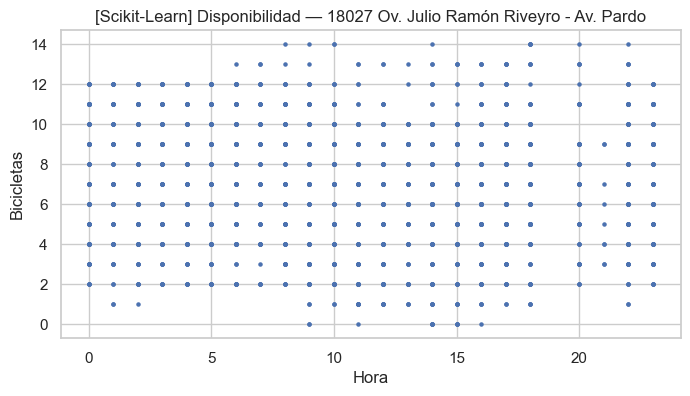

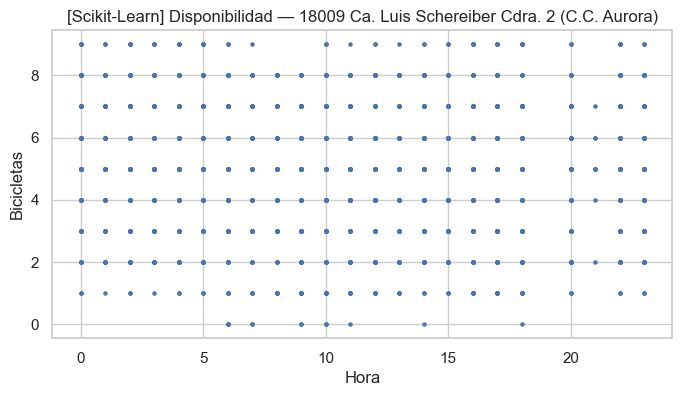

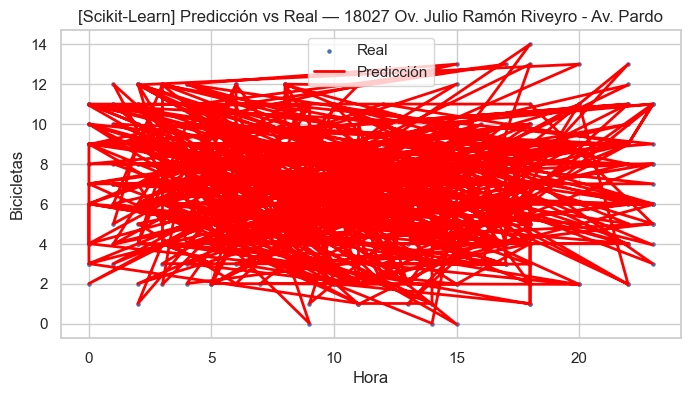

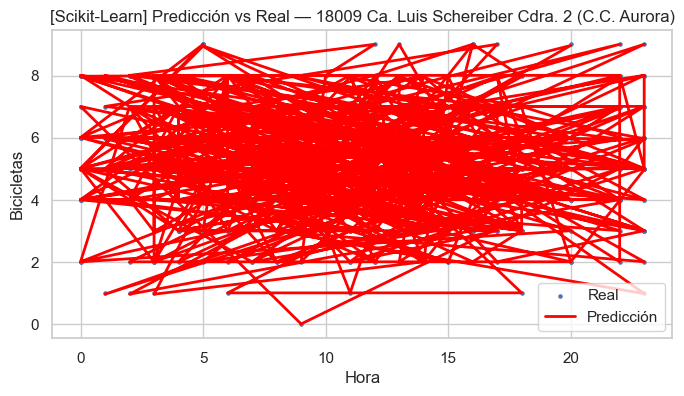

In [134]:
# ================================================
# CELDA 1 — REGRESIÓN LINEAL con Scikit-Learn
# ================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Modelo Lineal
lin_reg = LinearRegression()
lin_reg.fit(X_train_proc, y_train_arr)

# Predicciones
y_pred_lr = lin_reg.predict(X_test_proc).flatten()

# Métricas
rmse_lr = np.sqrt(mean_squared_error(y_test_arr, y_pred_lr))
r2_lr = r2_score(y_test_arr, y_pred_lr)
mae_lr = mean_absolute_error(y_test_arr, y_pred_lr)

print(f"[Scikit-Learn] RMSE: {rmse_lr:.4f}, R2: {r2_lr:.4f}, MAE: {mae_lr:.4f}")

# ---- Preparar DF para graficar ----
X_test_lr = X_test.copy()
X_test_lr['station_name'] = df.loc[X_test.index, 'station_name'].values
X_test_lr['hour'] = df.loc[X_test.index, 'hour'].values
X_test_lr['y_real'] = y_test_arr
X_test_lr['y_pred'] = y_pred_lr

stations = df['station_name'].unique()[:2]
target_col = "free_bikes"

# ---- Gráfica de disponibilidad ----
for station in stations:
    df_station = df[df['station_name'] == station]

    plt.figure(figsize=(8,4))
    plt.scatter(df_station['hour'], df_station[target_col], s=5)
    plt.title(f"[Scikit-Learn] Disponibilidad — {station}")
    plt.xlabel("Hora")
    plt.ylabel("Bicicletas")
    plt.grid(True)
    plt.show()

# ---- Gráfica Predicción vs Real ----
for station in stations:
    df_pred = X_test_lr[X_test_lr['station_name'] == station]

    plt.figure(figsize=(8,4))
    plt.scatter(df_pred['hour'], df_pred['y_real'], s=5, label="Real")
    plt.plot(df_pred['hour'], df_pred['y_pred'], linewidth=2, color="red", label="Predicción")

    plt.title(f"[Scikit-Learn] Predicción vs Real — {station}")
    plt.xlabel("Hora")
    plt.ylabel("Bicicletas")
    plt.legend()
    plt.grid(True)
    plt.show()


Theta calculada vía lstsq (SVD)
[LSTSQ-SVD] RMSE: 0.0837, R2: 0.9996, MAE: 0.0244


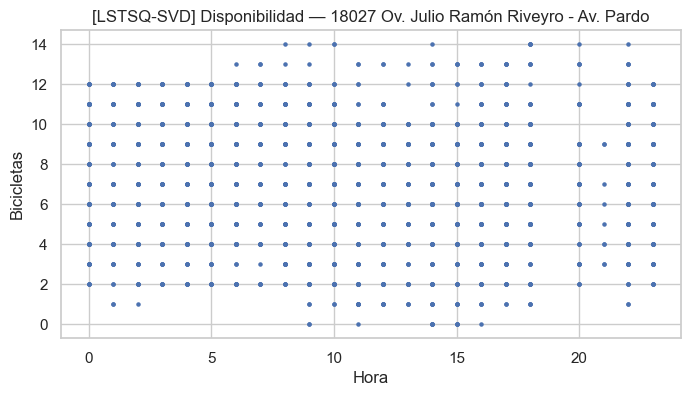

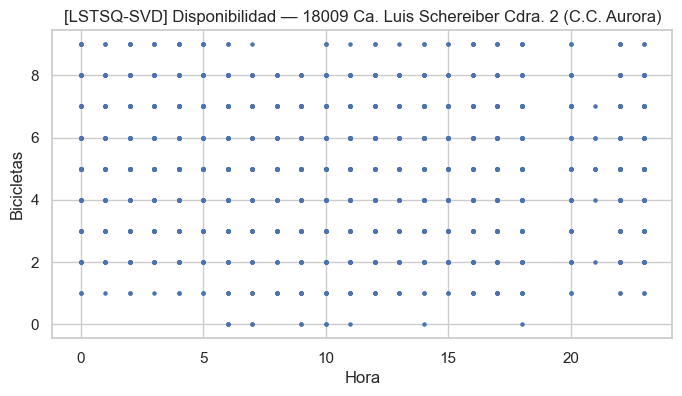

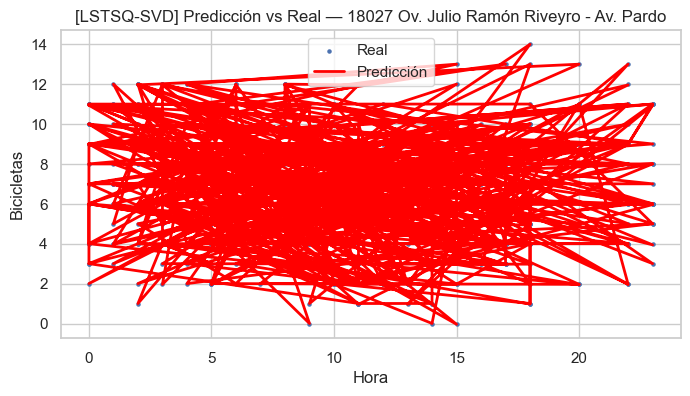

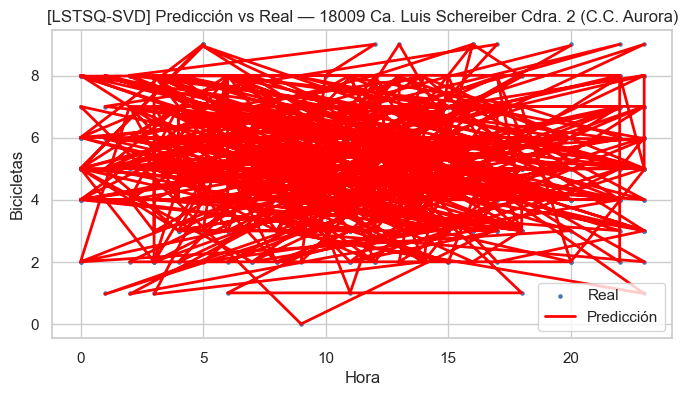

In [135]:
# ============================================================
# CELDA 2 — ECUACIÓN NORMAL usando LSTSQ (SVD)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Construir matrices con término bias
Xb = np.c_[np.ones((X_train_proc.shape[0], 1)), X_train_proc]
Xb_test = np.c_[np.ones((X_test_proc.shape[0], 1)), X_test_proc]

# Resolver con SVD (lstsq)
theta_svd, residuals, rank, s = np.linalg.lstsq(Xb, y_train_arr, rcond=1e-6)
print("Theta calculada vía lstsq (SVD)")

# Predicción
y_pred_svd = Xb_test.dot(theta_svd).flatten()

# Métricas
rmse_svd = np.sqrt(mean_squared_error(y_test_arr, y_pred_svd))
r2_svd = r2_score(y_test_arr, y_pred_svd)
mae_svd = mean_absolute_error(y_test_arr, y_pred_svd)

print(f"[LSTSQ-SVD] RMSE: {rmse_svd:.4f}, R2: {r2_svd:.4f}, MAE: {mae_svd:.4f}")

# ---- Preparar DF para graficar ----
X_test_svd = X_test.copy()
X_test_svd['station_name'] = df.loc[X_test.index, 'station_name'].values
X_test_svd['hour'] = df.loc[X_test.index, 'hour'].values
X_test_svd['y_real'] = y_test_arr
X_test_svd['y_pred'] = y_pred_svd

stations = df['station_name'].unique()[:2]
target_col = "free_bikes"

# ---- Gráfica de disponibilidad ----
for station in stations:
    df_station = df[df['station_name'] == station]

    plt.figure(figsize=(8,4))
    plt.scatter(df_station['hour'], df_station[target_col], s=5)
    plt.title(f"[LSTSQ-SVD] Disponibilidad — {station}")
    plt.xlabel("Hora")
    plt.ylabel("Bicicletas")
    plt.grid(True)
    plt.show()

# ---- Gráfica Predicción vs Real ----
for station in stations:
    df_pred = X_test_svd[X_test_svd['station_name'] == station]

    plt.figure(figsize=(8,4))
    plt.scatter(df_pred['hour'], df_pred['y_real'], s=5, label="Real")
    plt.plot(df_pred['hour'], df_pred['y_pred'], linewidth=2, color="red", label="Predicción")

    plt.title(f"[LSTSQ-SVD] Predicción vs Real — {station}")
    plt.xlabel("Hora")
    plt.ylabel("Bicicletas")
    plt.legend()
    plt.grid(True)
    plt.show()


Theta calculada vía pseudoinversa (pinv)
[PINV] RMSE: 0.0837, R2: 0.9996, MAE: 0.0244


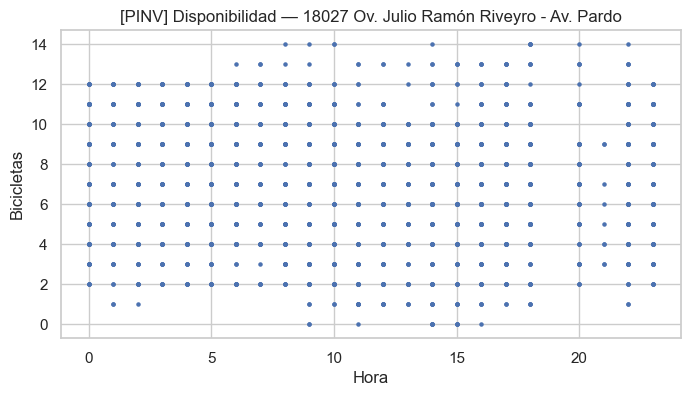

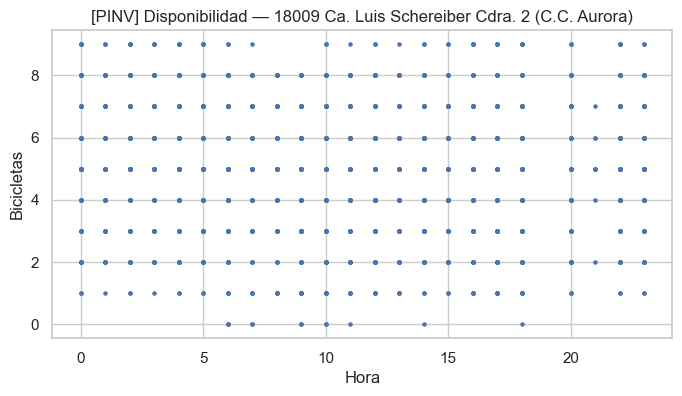

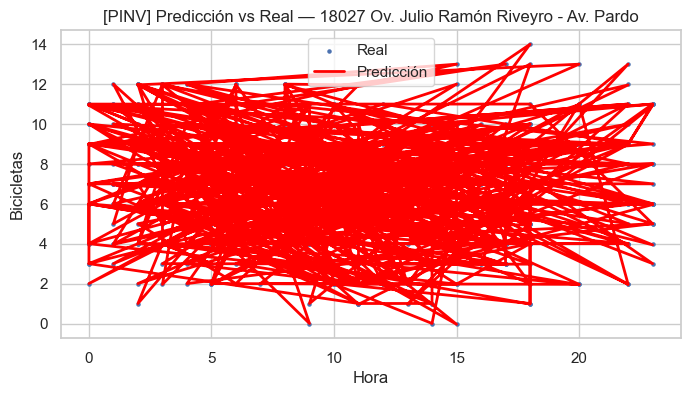

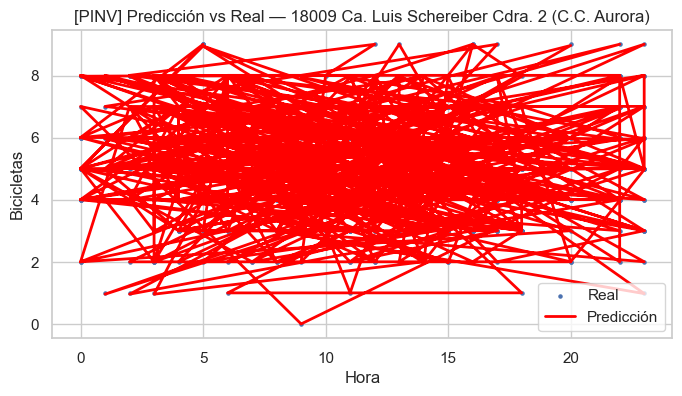

In [136]:
# ============================================================
# CELDA 3 — ECUACIÓN NORMAL usando PSEUDOINVERSA (pinv)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Construir matrices con término bias
Xb = np.c_[np.ones((X_train_proc.shape[0], 1)), X_train_proc]
Xb_test = np.c_[np.ones((X_test_proc.shape[0], 1)), X_test_proc]

# Resolver con pseudoinversa
theta_pinv = np.linalg.pinv(Xb).dot(y_train_arr)
print("Theta calculada vía pseudoinversa (pinv)")

# Predicción
y_pred_pinv = Xb_test.dot(theta_pinv).flatten()

# Métricas
rmse_pinv = np.sqrt(mean_squared_error(y_test_arr, y_pred_pinv))
r2_pinv = r2_score(y_test_arr, y_pred_pinv)
mae_pinv = mean_absolute_error(y_test_arr, y_pred_pinv)

print(f"[PINV] RMSE: {rmse_pinv:.4f}, R2: {r2_pinv:.4f}, MAE: {mae_pinv:.4f}")

# ---- Preparar DF para graficar ----
X_test_pinv = X_test.copy()
X_test_pinv['station_name'] = df.loc[X_test.index, 'station_name'].values
X_test_pinv['hour'] = df.loc[X_test.index, 'hour'].values
X_test_pinv['y_real'] = y_test_arr
X_test_pinv['y_pred'] = y_pred_pinv

stations = df['station_name'].unique()[:2]
target_col = "free_bikes"

# ---- Gráfica de disponibilidad ----
for station in stations:
    df_station = df[df['station_name'] == station]

    plt.figure(figsize=(8,4))
    plt.scatter(df_station['hour'], df_station[target_col], s=5)
    plt.title(f"[PINV] Disponibilidad — {station}")
    plt.xlabel("Hora")
    plt.ylabel("Bicicletas")
    plt.grid(True)
    plt.show()

# ---- Gráfica Predicción vs Real ----
for station in stations:
    df_pred = X_test_pinv[X_test_pinv['station_name'] == station]

    plt.figure(figsize=(8,4))
    plt.scatter(df_pred['hour'], df_pred['y_real'], s=5, label="Real")
    plt.plot(df_pred['hour'], df_pred['y_pred'], linewidth=2, color="red", label="Predicción")

    plt.title(f"[PINV] Predicción vs Real — {station}")
    plt.xlabel("Hora")
    plt.ylabel("Bicicletas")
    plt.legend()
    plt.grid(True)
    plt.show()


In [137]:
# ===============================================================
# CELDA — COMPARACIÓN ENTRE 3 MÉTODOS DE REGRESIÓN LINEAL
# Scikit-Learn  |  np.linalg.lstsq (SVD)  |  np.linalg.pinv
# ===============================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

resultados = []

# ===============================================================
# 1️⃣ Scikit-Learn (usa SVD internamente mediante scipy.linalg.lstsq)
# ===============================================================
lin_reg = LinearRegression()
lin_reg.fit(X_train_proc, y_train_arr)

y_pred_lr = lin_reg.predict(X_test_proc).flatten()

resultados.append({
    "Método": "Scikit-Learn",
    "RMSE": np.sqrt(mean_squared_error(y_test_arr, y_pred_lr)),
    "R2": r2_score(y_test_arr, y_pred_lr),
    "MAE": mean_absolute_error(y_test_arr, y_pred_lr)
})


# Crear matrices con bias
Xb = np.c_[np.ones((X_train_proc.shape[0], 1)), X_train_proc]
Xb_test = np.c_[np.ones((X_test_proc.shape[0], 1)), X_test_proc]


# ===============================================================
# 2️⃣ LSTSQ (SVD)
# ===============================================================
theta_svd, residuals, rank, s = np.linalg.lstsq(Xb, y_train_arr, rcond=1e-6)
y_pred_svd = Xb_test.dot(theta_svd).flatten()

resultados.append({
    "Método": "LSTSQ (SVD)",
    "RMSE": np.sqrt(mean_squared_error(y_test_arr, y_pred_svd)),
    "R2": r2_score(y_test_arr, y_pred_svd),
    "MAE": mean_absolute_error(y_test_arr, y_pred_svd)
})


# ===============================================================
# 3️⃣ Pseudoinversa (PINV)
# ===============================================================
theta_pinv = np.linalg.pinv(Xb).dot(y_train_arr)
y_pred_pinv = Xb_test.dot(theta_pinv).flatten()

resultados.append({
    "Método": "Pseudoinversa (PINV)",
    "RMSE": np.sqrt(mean_squared_error(y_test_arr, y_pred_pinv)),
    "R2": r2_score(y_test_arr, y_pred_pinv),
    "MAE": mean_absolute_error(y_test_arr, y_pred_pinv)
})


# ===============================================================
# Mostrar tabla comparativa
# ===============================================================

df_comparacion = pd.DataFrame(resultados)
print("\n=== COMPARACIÓN DE MÉTODOS ===\n")
display(df_comparacion)



=== COMPARACIÓN DE MÉTODOS ===



,Método,RMSE,R2,MAE
0,Scikit-Learn,0.083693,0.999611,0.024424
1,LSTSQ (SVD),0.083693,0.999611,0.024424
2,Pseudoinversa (PINV),0.083693,0.999611,0.024424
